# Notebook 17: Introduction to Neural Networks with Keras/TensorFlow
## Part 17/30 – ML Mastery Series for Python Experts

## From Linear Models to Neural Networks – The Leap

You already know powerful classical models — now let's build something that can learn almost anything, layer by layer, using nothing but gradients… welcome to deep learning.

- **Universal function approximators**: A neural network with enough hidden units can approximate any continuous function (Universal Approximation Theorem)
- **Non-linear decision boundaries via activations**: Unlike linear models, neural nets can carve complex, curved decision boundaries through non-linear activation functions
- **Layered representation learning**: Each hidden layer learns increasingly abstract features (edges → shapes → objects in vision, or n-grams → phrases → concepts in NLP)
- **Gradient-based optimization**: We optimize millions of parameters simultaneously using automatic differentiation and backpropagation
- **End-to-end differentiability**: The entire computation graph is differentiable, enabling seamless optimization from input to output
- **But black-box & data-hungry**: Neural networks are less interpretable than decision trees or linear models, typically require more data, and are computationally expensive
- **Scalable architecture**: The same fundamental building blocks (layers, activations, losses) scale from simple tabular data to massive computer vision and NLP systems

## Learning Objectives

By the end of this notebook, you will be able to:

- Build Sequential and Functional API models in Keras for various tasks
- Choose and understand activation functions (ReLU, sigmoid, tanh, softmax) and their appropriate use cases
- Define loss functions and metrics for both classification and regression problems
- Use common optimizers effectively (Adam, SGD with momentum) and understand their hyperparameters
- Train models with `.fit()` and leverage callbacks for monitoring and control
- Visualize training history (loss/accuracy curves) to diagnose convergence issues
- Interpret model weights and activations to gain insight into what the network learned
- Avoid and debug common pitfalls: vanishing gradients, exploding gradients, and overfitting
- Implement early stopping and model checkpointing to prevent wasted computation
- Compare neural network performance against classical baselines (e.g., LinearRegression)

## 🧠 1. Your First Neural Network – Binary Classification (Breast Cancer)

We'll start with the classic breast cancer dataset — a clean, small tabular dataset perfect for learning the Keras workflow without GPU requirements.

In [1]:
# Standard imports for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set visualization style
%matplotlib inline
sns.set_theme(style="whitegrid")
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [2]:
# Load the breast cancer dataset (569 samples, 30 features)
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}, Classes: {np.unique(y)}")
print(f"Class distribution: {np.bincount(y)} (0=malignant, 1=benign)")

Features: 30, Samples: 569, Classes: [0 1]
Class distribution: [212 357] (0=malignant, 1=benign)


In [3]:
# Split into train and test with stratification to maintain class balance
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (455, 30), Test: (114, 30)


In [4]:
# Standardize features - CRITICAL for neural networks
# Neural nets are sensitive to input scales; unscaled inputs lead to poor convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Only transform, never fit on test data

In [5]:
# Build our first neural network using the Sequential API
# Architecture: Input(30) → Dense(16, relu) → Dense(8, relu) → Dense(1, sigmoid)
model = keras.Sequential([
    layers.Input(shape=(30,)),  # Explicit input layer with 30 features
    layers.Dense(16, activation='relu', name='hidden_1'),  # First hidden layer
    layers.Dense(8, activation='relu', name='hidden_2'),   # Second hidden layer
    layers.Dense(1, activation='sigmoid', name='output')  # Binary output
], name='breast_cancer_classifier')

# Display model architecture
model.summary()

Model: "breast_cancer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile the model: define optimizer, loss function, and metrics
model.compile(
    optimizer='adam',  # Adaptive moment estimation - generally best default choice
    loss='binary_crossentropy',  # Standard for binary classification (log loss)
    metrics=['accuracy', 'AUC']  # Track accuracy and Area Under ROC Curve
)
# Note: AUC is especially useful for imbalanced datasets

In [7]:
# Train the model with validation split
# validation_split=0.2 reserves 20% of training data for validation
# This helps us monitor for overfitting during training
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1  # Set to 0 for silent, 2 for per-epoch only
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - AUC: 0.5078 - accuracy: 0.3187 - loss: 0.7819 - val_AUC: 0.6616 - val_accuracy: 0.4396 - val_loss: 0.6962
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - AUC: 0.7080 - accuracy: 0.5330 - loss: 0.6446 - val_AUC: 0.7651 - val_accuracy: 0.6484 - val_loss: 0.6059
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - AUC: 0.8661 - accuracy: 0.7637 - loss: 0.5646 - val_AUC: 0.8806 - val_accuracy: 0.7363 - val_loss: 0.5424
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - AUC: 0.9395 - accuracy: 0.8736 - loss: 0.5026 - val_AUC: 0.9320 - val_accuracy: 0.8242 - val_loss: 0.4881
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - AUC: 0.9690 - accuracy: 0.8874 - loss: 0.4476 - val_AUC: 0.9625 - val_accuracy: 0.8901 - val_loss: 0.4330
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - AUC: 0.9784 - accuracy: 0.9038 - loss: 0.3939 - val_AUC: 0.9806 - val_accuracy: 0.9011 - val_loss: 0.3800
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/

In [8]:
# Evaluate on the held-out test set
test_loss, test_acc, test_auc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

Test Loss: 0.0922
Test Accuracy: 0.9649
Test AUC: 0.9921


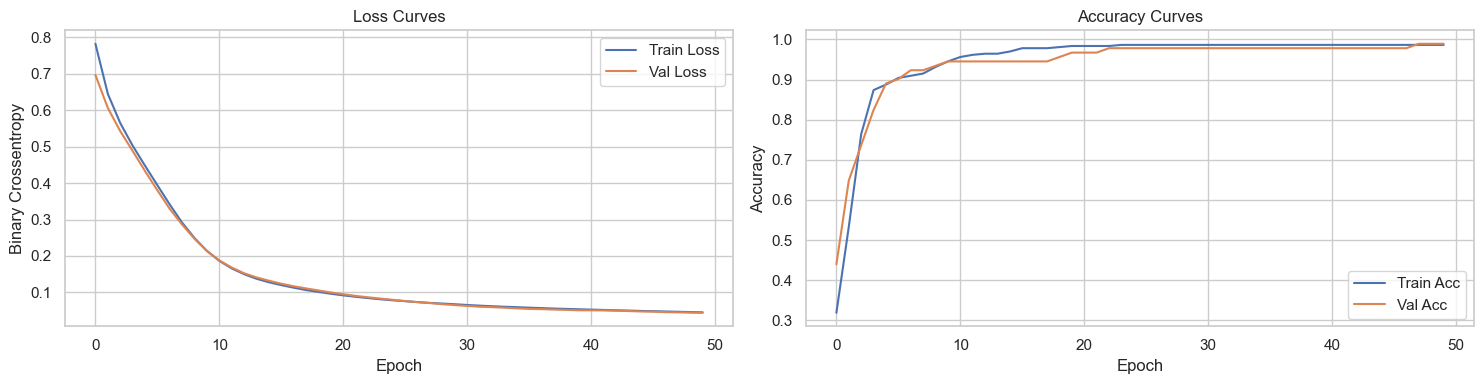

In [9]:
# Visualize training history - essential for diagnosing convergence issues
# Check what metrics are available in history
available_metrics = list(history.history.keys())
n_plots = 2 if 'auc' not in available_metrics else 3
fig, axes = plt.subplots(1, n_plots, figsize=(15, 4))

# Plot loss curves
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True)

# Plot accuracy curves
axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# Plot AUC curves if available
if 'auc' in available_metrics:
    axes[2].plot(history.history['auc'], label='Train AUC')
    axes[2].plot(history.history['val_auc'], label='Val AUC')
    axes[2].set_title('AUC Curves')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('AUC')
    axes[2].legend()
    axes[2].grid(True)

plt.tight_layout()
plt.show()
# Key observation: If val_loss starts increasing while train_loss decreases → overfitting

## ⚡ 2. Understanding Activations & Their Effects

Activation functions introduce non-linearity. Without them, a deep neural network would just be a linear model. Let's compare ReLU, sigmoid, and tanh in hidden layers to see how they affect learning dynamics.

In [10]:
# Helper function to build models with different hidden activations
def build_model(hidden_activation='relu'):
    """Build a binary classifier with specified hidden activation."""
    model = keras.Sequential([
        layers.Input(shape=(30,)),
        layers.Dense(16, activation=hidden_activation),
        layers.Dense(8, activation=hidden_activation),
        layers.Dense(1, activation='sigmoid')  # Output always sigmoid for binary
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train three identical architectures with different activations
activations = ['relu', 'sigmoid', 'tanh']
histories = {}

for act in activations:
    print(f"\nTraining with {act} activation...")
    model = build_model(act)
    # Use fewer epochs for comparison since we're just demonstrating differences
    h = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        verbose=0  # Suppress output for cleaner comparison
    )
    histories[act] = h


Training with relu activation...

Training with sigmoid activation...

Training with tanh activation...


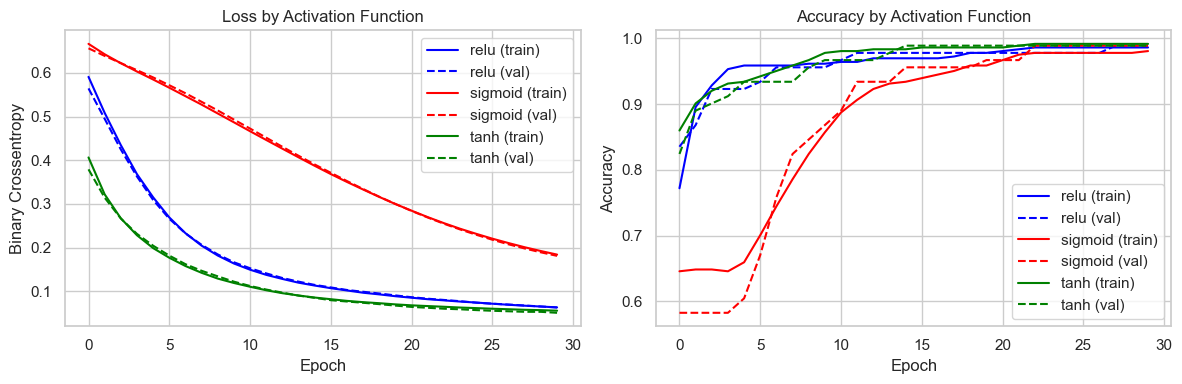

Key insights:
• ReLU: Fastest convergence, avoids vanishing gradients (gradient = 1 for x > 0)
• Sigmoid: Suffers from vanishing gradients when saturated (|x| > 5)
• Tanh: Zero-centered (better than sigmoid) but still suffers from saturation


In [11]:
# Compare training curves side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'relu': 'blue', 'sigmoid': 'red', 'tanh': 'green'}

for act, h in histories.items():
    # Training loss
    axes[0].plot(h.history['loss'], label=f'{act} (train)', 
                color=colors[act], linestyle='-')
    axes[0].plot(h.history['val_loss'], label=f'{act} (val)', 
                color=colors[act], linestyle='--')
    
    # Training accuracy
    axes[1].plot(h.history['accuracy'], label=f'{act} (train)', 
                color=colors[act], linestyle='-')
    axes[1].plot(h.history['val_accuracy'], label=f'{act} (val)', 
                color=colors[act], linestyle='--')

axes[0].set_title('Loss by Activation Function')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Accuracy by Activation Function')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Key insights:")
print("• ReLU: Fastest convergence, avoids vanishing gradients (gradient = 1 for x > 0)")
print("• Sigmoid: Suffers from vanishing gradients when saturated (|x| > 5)")
print("• Tanh: Zero-centered (better than sigmoid) but still suffers from saturation")

### Activation Function Deep Dive

**ReLU (Rectified Linear Unit)**: $f(x) = \max(0, x)$
- Pros: Computationally cheap, no saturation for positive values, sparse activation
- Cons: "Dying ReLU" problem (neurons can get stuck at 0 if weights push all inputs negative)

**Sigmoid**: $f(x) = \frac{1}{1 + e^{-x}}$
- Pros: Smooth, outputs in (0,1) → natural for probabilities
- Cons: Vanishing gradients for |x| > 5, outputs not zero-centered

**Tanh**: $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
- Pros: Zero-centered outputs (-1, 1), stronger gradients than sigmoid
- Cons: Still suffers from saturation/vanishing gradients

## 🌸 3. Multiclass Classification – Iris Dataset

Now let's tackle multiclass classification using the Iris dataset. Key differences:
- Output layer has `n_classes` neurons with **softmax** activation
- Loss function is **categorical_crossentropy** (or sparse_categorical_crossentropy if labels are integers)
- We use `to_categorical` to one-hot encode labels

In [12]:
from sklearn.datasets import load_iris
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# Load Iris dataset (150 samples, 4 features, 3 classes)
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
class_names = iris.target_names
print(f"Features: {X_iris.shape[1]}, Classes: {len(np.unique(y_iris))}")
print(f"Class names: {class_names}")

Features: 4, Classes: 3
Class names: ['setosa' 'versicolor' 'virginica']


In [13]:
# Split and scale
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, stratify=y_iris, random_state=42
)
scaler_i = StandardScaler()
X_train_i_scaled = scaler_i.fit_transform(X_train_i)
X_test_i_scaled = scaler_i.transform(X_test_i)

In [14]:
# Convert integer labels to one-hot encoding for categorical_crossentropy
# Alternative: use sparse_categorical_crossentropy loss with integer labels directly
y_train_i_cat = to_categorical(y_train_i, num_classes=3)
y_test_i_cat = to_categorical(y_test_i, num_classes=3)
print(f"Original label: {y_train_i[0]} → One-hot: {y_train_i_cat[0]}")

Original label: 0 → One-hot: [1. 0. 0.]


In [15]:
# Build multiclass classifier
# Architecture: 4 → 32 → 16 → 3 (softmax)
model_i = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax', name='output')  # 3 classes with softmax
], name='iris_multiclass')

model_i.summary()

Model: "iris_multiclass"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compile with categorical_crossentropy (expects one-hot labels)
model_i.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_i = model_i.fit(
    X_train_i_scaled, y_train_i_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0
)
print("Training complete!")

Training complete!


In [17]:
# Evaluate
test_loss_i, test_acc_i = model_i.evaluate(X_test_i_scaled, y_test_i_cat, verbose=0)
print(f"Test Accuracy: {test_acc_i:.4f}")

# Predictions for confusion matrix
y_pred_probs = model_i.predict(X_test_i_scaled, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class indices

print("\nClassification Report:")
print(classification_report(y_test_i, y_pred, target_names=class_names))

Test Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



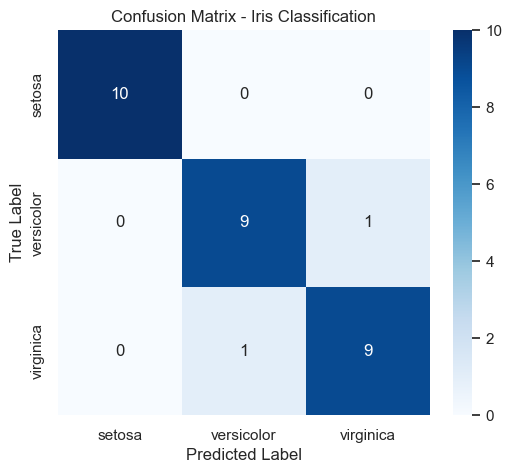

In [18]:
# Visualize confusion matrix
cm = confusion_matrix(y_test_i, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Iris Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

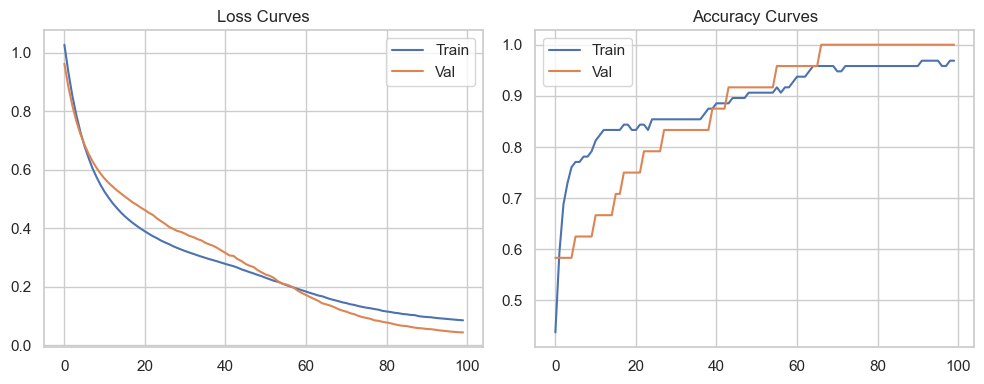

In [19]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_i.history['loss'], label='Train')
axes[0].plot(history_i.history['val_loss'], label='Val')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[1].plot(history_i.history['accuracy'], label='Train')
axes[1].plot(history_i.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy Curves')
axes[1].legend()
plt.tight_layout()
plt.show()

## 🏠 4. Regression with Neural Nets – California Housing

Neural networks aren't just for classification! For regression:
- Output layer has 1 neuron with **linear activation** (or no activation, i.e., `activation=None`)
- Loss function is typically **MSE** (Mean Squared Error) or **MAE** (Mean Absolute Error)
- Metrics usually include MAE and RMSE

In [20]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load California housing dataset (20,640 samples, 8 features)
# Target: median house value in $100,000s
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
print(f"Features: {X_h.shape[1]}, Samples: {X_h.shape[0]}")
print(f"Target range: [{y_h.min():.2f}, {y_h.max():.2f}] ($100k units)")

Features: 8, Samples: 20640
Target range: [0.15, 5.00] ($100k units)


In [21]:
# Split into train/validation/test (60/20/20)
# Using validation set for early stopping decisions
X_train_h, X_temp_h, y_train_h, y_temp_h = train_test_split(
    X_h, y_h, test_size=0.4, random_state=42
)
X_val_h, X_test_h, y_val_h, y_test_h = train_test_split(
    X_temp_h, y_temp_h, test_size=0.5, random_state=42
)
print(f"Train: {X_train_h.shape}, Val: {X_val_h.shape}, Test: {X_test_h.shape}")

Train: (12384, 8), Val: (4128, 8), Test: (4128, 8)


In [22]:
# Scale features (essential!)
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_val_h_scaled = scaler_h.transform(X_val_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

In [23]:
# Build regression model
# Note: No activation in final layer → linear output
model_h = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation=None)  # Linear output for regression
], name='housing_regressor')

model_h.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error
    metrics=['mae']  # Mean Absolute Error
)
model_h.summary()

Model: "housing_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Train with explicit validation data (not validation_split)
history_h = model_h.fit(
    X_train_h_scaled, y_train_h,
    validation_data=(X_val_h_scaled, y_val_h),
    epochs=100,
    batch_size=32,
    verbose=0
)
print("Training complete!")

Training complete!


In [25]:
# Evaluate on test set
test_loss_h, test_mae_h = model_h.evaluate(X_test_h_scaled, y_test_h, verbose=0)
print(f"Test MSE: {test_loss_h:.4f}")
print(f"Test MAE: {test_mae_h:.4f} (=$ {test_mae_h*100000:.0f})")

# Get predictions for visualization
y_pred_h = model_h.predict(X_test_h_scaled, verbose=0).flatten()

Test MSE: 0.2704
Test MAE: 0.3549 (=$ 35489)


In [26]:
# Compare to Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train_h_scaled, y_train_h)
y_pred_lr = lr.predict(X_test_h_scaled)
lr_mae = mean_absolute_error(y_test_h, y_pred_lr)
print(f"Linear Regression MAE: {lr_mae:.4f} (=$ {lr_mae*100000:.0f})")
print(f"Neural Net MAE: {test_mae_h:.4f} (=$ {test_mae_h*100000:.0f})")
print(f"Improvement: {(1 - test_mae_h/lr_mae)*100:.1f}%")

Linear Regression MAE: 0.5338 (=$ 53376)
Neural Net MAE: 0.3549 (=$ 35489)
Improvement: 33.5%


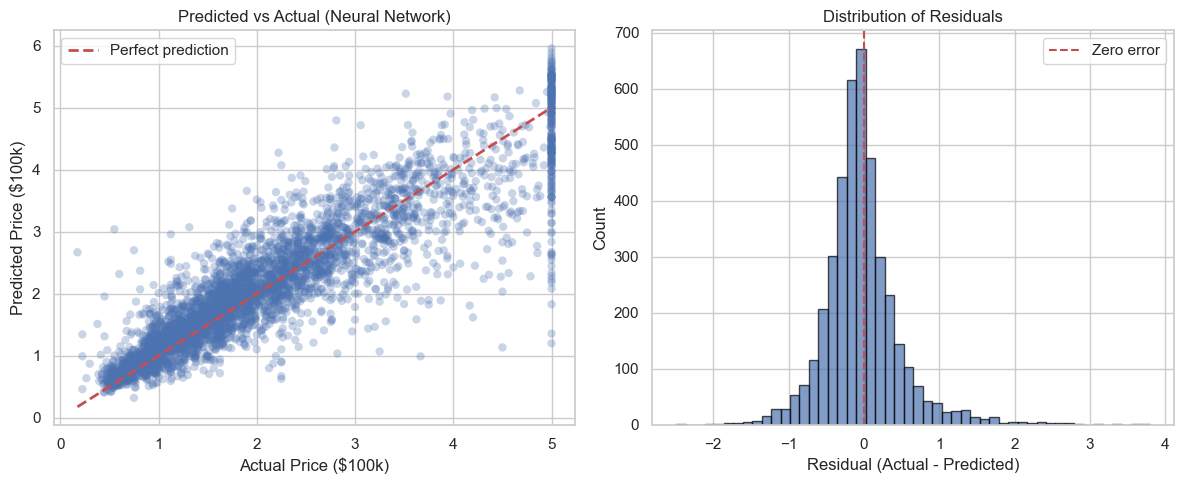

In [27]:
# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs Actual scatter plot
axes[0].scatter(y_test_h, y_pred_h, alpha=0.3, edgecolors='none')
axes[0].plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 
            'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($100k)')
axes[0].set_ylabel('Predicted Price ($100k)')
axes[0].set_title('Predicted vs Actual (Neural Network)')
axes[0].legend()
axes[0].grid(True)

# Residual histogram
residuals = y_test_h - y_pred_h
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', label='Zero error')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')
axes[1].legend()

plt.tight_layout()
plt.show()
# Ideal residual distribution: centered at 0, roughly normal, no obvious patterns

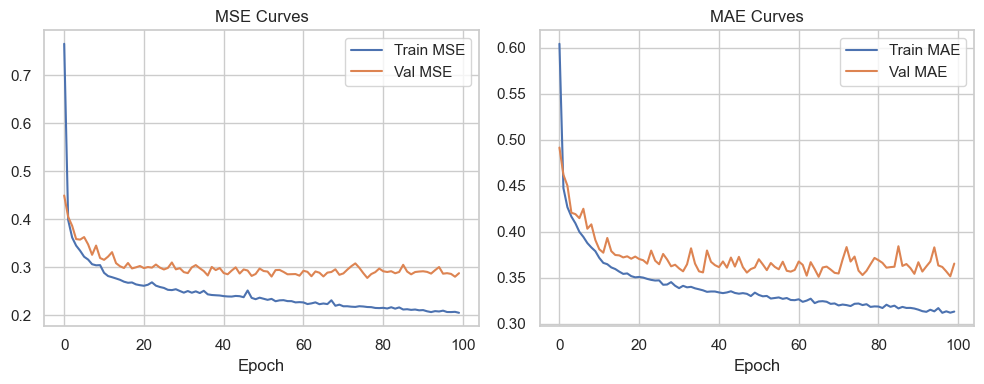

In [28]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_h.history['loss'], label='Train MSE')
axes[0].plot(history_h.history['val_loss'], label='Val MSE')
axes[0].set_title('MSE Curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_h.history['mae'], label='Train MAE')
axes[1].plot(history_h.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE Curves')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()
# Note the plateau around epoch 50 - we could have stopped early!

## 🛑 5. Callbacks & Early Stopping – Preventing Overfitting

Callbacks are powerful tools to control training dynamically. We'll use:
- **EarlyStopping**: Halt training when validation loss stops improving
- **ModelCheckpoint**: Save the best model weights automatically
- **ReduceLROnPlateau**: Decrease learning rate when stuck in plateau

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Rebuild the housing model for this demonstration
model_cb = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation=None)
])

model_cb.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [30]:
# Define callbacks
callbacks = [
    # Stop training if val_loss doesn't improve for 10 epochs
    # restore_best_weights=True rolls back to the best epoch, not the last
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Save the best model based on validation loss
    ModelCheckpoint(
        'best_model.h5',  # File path
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    
    # Reduce learning rate when val_loss plateaus
    # factor=0.5 means new_lr = lr * 0.5
    # patience=5 means wait 5 epochs before reducing
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [31]:
# Train with callbacks - will likely stop before 200 epochs
history_cb = model_cb.fit(
    X_train_h_scaled, y_train_h,
    validation_data=(X_val_h_scaled, y_val_h),
    epochs=200,  # Set high, EarlyStopping will cut it short
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print(f"\nTraining stopped at epoch {len(history_cb.history['loss'])}")

Epoch 1/200
380/387 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5803 - mae: 0.8684
Epoch 1: val_loss improved from None to 0.46415, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.8887 - mae: 0.6435 - val_loss: 0.4642 - val_mae: 0.4925 - learning_rate: 0.0010
Epoch 2/200
380/387 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4130 - mae: 0.4615
Epoch 2: val_loss improved from 0.46415 to 0.40318, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4124 - mae: 0.4578 - val_loss: 0.4032 - val_mae: 0.4515 - learning_rate: 0.0010
Epoch 3/200
369/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3899 - mae: 0.4432
Epoch 3: val_loss improved from 0.40318 to 0.38698, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3731 - mae: 0.4341 - val_loss: 0.3870 - val_mae: 0.4335 - learning_rate: 0.0010
Epoch 4/200
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3645 - mae: 0.4244
Epoch 4: val_loss improved from 0.38698 to 0.38641, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3552 - mae: 0.4210 - val_loss: 0.3864 - val_mae: 0.4286 - learning_rate: 0.0010
Epoch 5/200
382/387 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3327 - mae: 0.4056
Epoch 5: val_loss improved from 0.38641 to 0.37797, saving model to best_model.h5


...


Epoch 50: finished saving model to best_model.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2360 - mae: 0.3304 - val_loss: 0.2800 - val_mae: 0.3563 - learning_rate: 2.5000e-04
Epoch 51/200
381/387 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2278 - mae: 0.3250
Epoch 51: val_loss did not improve from 0.27996
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2347 - mae: 0.3288 - val_loss: 0.2808 - val_mae: 0.3579 - learning_rate: 2.5000e-04
Epoch 52/200
383/387 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2369 - mae: 0.3280
Epoch 52: val_loss did not improve from 0.27996
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2343 - mae: 0.3289 - val_loss: 0.2815 - val_mae: 0.3590 - learning_rate: 2.5000e-04
Epoch 53/200
378/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2371 - mae: 0.3287
Epoch 53: val_loss did not improve from 0.27996
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2343 - mae: 0.3281 - val_loss: 0.2819 - val_mae: 0.3608 - learning_rate: 2.5000e-04
Epoch 54/200
387/


Epoch 55: finished saving model to best_model.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2335 - mae: 0.3278 - val_loss: 0.2790 - val_mae: 0.3568 - learning_rate: 2.5000e-04
Epoch 56/200
377/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2363 - mae: 0.3306
Epoch 56: val_loss did not improve from 0.27898
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2331 - mae: 0.3277 - val_loss: 0.2796 - val_mae: 0.3548 - learning_rate: 2.5000e-04
Epoch 57/200
374/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2353 - mae: 0.3266
Epoch 57: val_loss did not improve from 0.27898
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2327 - mae: 0.3273 - val_loss: 0.2880 - val_mae: 0.3702 - learning_rate: 2.5000e-04
Epoch 58/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2284 - mae: 0.3253
Epoch 58: val_loss improved from 0.27898 to 0.27767, saving model to best_model.h5



Epoch 58: finished saving model to best_model.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2322 - mae: 0.3269 - val_loss: 0.2777 - val_mae: 0.3580 - learning_rate: 2.5000e-04
Epoch 59/200
384/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2381 - mae: 0.3323
Epoch 59: val_loss did not improve from 0.27767
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2317 - mae: 0.3269 - val_loss: 0.2795 - val_mae: 0.3574 - learning_rate: 2.5000e-04
Epoch 60/200
380/387 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2285 - mae: 0.3254
Epoch 60: val_loss did not improve from 0.27767
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2320 - mae: 0.3273 - val_loss: 0.2813 - val_mae: 0.3577 - learning_rate: 2.5000e-04
Epoch 61/200
368/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2313 - mae: 0.3261
Epoch 61: val_loss did not improve from 0.27767
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2306 - mae: 0.3256 - val_loss: 0.2793 - val_mae: 0.3613 - learning_rate: 2.5000e-04
Epoch 62/200
376/


Epoch 62: finished saving model to best_model.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2305 - mae: 0.3262 - val_loss: 0.2769 - val_mae: 0.3568 - learning_rate: 2.5000e-04
Epoch 63/200
381/387 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2324 - mae: 0.3271
Epoch 63: val_loss improved from 0.27690 to 0.27611, saving model to best_model.h5



Epoch 63: finished saving model to best_model.h5
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2306 - mae: 0.3257 - val_loss: 0.2761 - val_mae: 0.3590 - learning_rate: 2.5000e-04
Epoch 64/200
383/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2180 - mae: 0.3194
Epoch 64: val_loss did not improve from 0.27611
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2295 - mae: 0.3259 - val_loss: 0.2847 - val_mae: 0.3565 - learning_rate: 2.5000e-04
Epoch 65/200
386/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2284 - mae: 0.3248
Epoch 65: val_loss did not improve from 0.27611
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2298 - mae: 0.3258 - val_loss: 0.2803 - val_mae: 0.3540 - learning_rate: 2.5000e-04
Epoch 66/200
378/387 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2279 - mae: 0.3261
Epoch 66: val_loss did not improve from 0.27611
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2297 - mae: 0.3255 - val_loss: 0.2805 - val_mae: 0.3629 - learning_rate: 2.5000e-04
Epoch 67/200
380/

In [32]:
# Verify we restored best weights (not final weights)
val_loss_final = model_cb.evaluate(X_val_h_scaled, y_val_h, verbose=0)[0]
print(f"Final validation MSE: {val_loss_final:.4f}")
print(f"Best validation MSE during training: {min(history_cb.history['val_loss']):.4f}")
print("These should match if restore_best_weights worked!")

Final validation MSE: 0.2761
Best validation MSE during training: 0.2761
These should match if restore_best_weights worked!


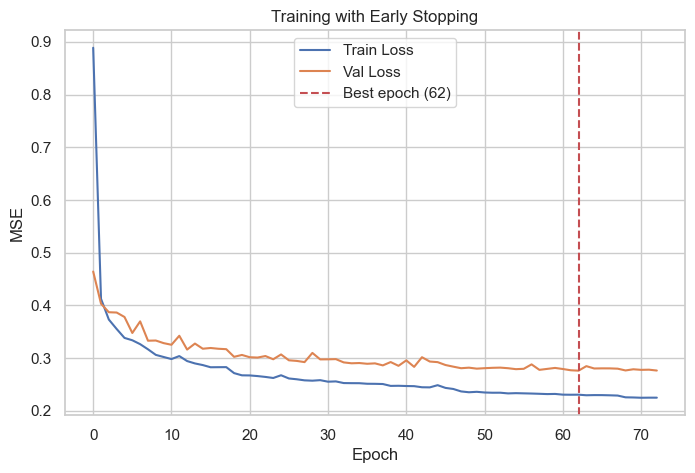

Early stopping saved us from 127 unnecessary epochs!


In [33]:
# Visualize the early stopping point
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_cb.history['loss'], label='Train Loss')
ax.plot(history_cb.history['val_loss'], label='Val Loss')

# Find best epoch
best_epoch = np.argmin(history_cb.history['val_loss'])
ax.axvline(x=best_epoch, color='r', linestyle='--', 
          label=f'Best epoch ({best_epoch})')

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Training with Early Stopping')
ax.legend()
ax.grid(True)
plt.show()
print(f"Early stopping saved us from {200 - len(history_cb.history['loss'])} unnecessary epochs!")

## 📊 6. Visualizing Learning Dynamics

Understanding how your model learns is crucial for debugging. We'll explore:
1. Standard history plots (loss/metrics vs epochs)
2. TensorBoard integration for interactive visualization
3. Simple activation visualization to peek inside the network

In [34]:
# Create a model with TensorBoard callback
from tensorflow.keras.callbacks import TensorBoard
import datetime

# Create logs directory with timestamp
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,  # Log weight histograms every epoch
    update_freq='epoch'
)

# To view in Jupyter, you would run:
# %load_ext tensorboard
# %tensorboard --logdir logs/fit
# For now, we'll demonstrate with a quick training run

model_viz = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(32, activation='relu', name='hidden_1'),
    layers.Dense(16, activation='relu', name='hidden_2'),
    layers.Dense(1, activation=None, name='output')
])
model_viz.compile(optimizer='adam', loss='mse')

In [35]:
# Quick training run with TensorBoard logging
# In practice, launch TensorBoard in terminal: tensorboard --logdir=logs/fit
history_viz = model_viz.fit(
    X_train_h_scaled, y_train_h,
    validation_data=(X_val_h_scaled, y_val_h),
    epochs=20,
    batch_size=32,
    callbacks=[tensorboard_callback],
    verbose=0
)
print(f"TensorBoard logs saved to: {log_dir}")
print("Run in terminal: tensorboard --logdir=logs/fit")

TensorBoard logs saved to: logs/fit/20260310-054821
Run in terminal: tensorboard --logdir=logs/fit


In [ ]:
# Simple activation visualization - extract intermediate layer outputs
# Ensure model is built and called to initialize input/output nodes
if not model_viz.built: model_viz.build((None, 8))
model_viz(np.zeros((1, 8))) # Dummy call to realize the graph
layer_outputs = [layer.output for layer in model_viz.layers if 'hidden' in layer.name]
activation_model = keras.Model(inputs=model_viz.input, outputs=layer_outputs)


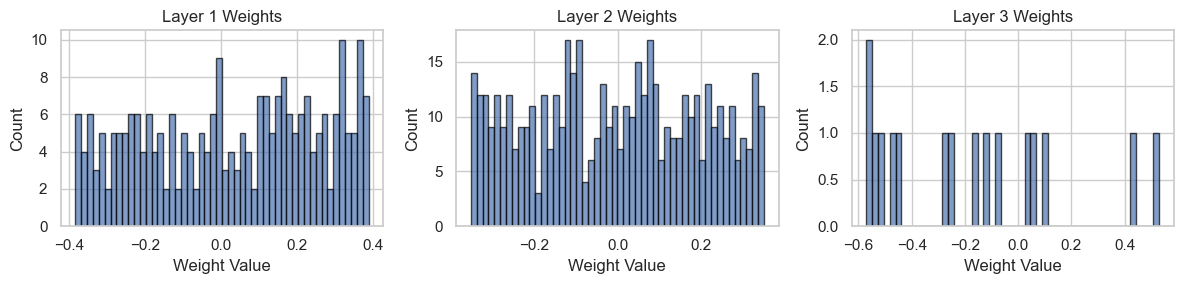

In [ ]:
# Weight visualization - check weight distributions
weights = model_viz.get_weights()
fig, axes = plt.subplots(1, len(weights)//2, figsize=(12, 3))
for i in range(0, len(weights), 2):  # Every other is weights (not biases)
    w = weights[i].flatten()
    ax = axes[i//2]
    ax.hist(w, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'Layer {i//2 + 1} Weights')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
# Healthy weights: roughly centered, no extreme outliers (would indicate exploding gradients)

## 🐛 7. Common Gotchas & Debugging Tips

Let's deliberately break things to learn how to fix them. This section demonstrates:
1. Overfitting with an overly complex model
2. Vanishing/exploding gradients with poor initialization/activation choices
3. Wrong loss/activation combinations
4. Batch size effects on convergence

In [ ]:
# GOTCHA 1: Severe overfitting with too many parameters
# Small dataset + huge network = memorization, not generalization

overfit_model = keras.Sequential([
    layers.Input(shape=(30,)),
    layers.Dense(512, activation='relu'),  # Way too big for this data
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
)

overfit_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_overfit = overfit_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=8,  # Small batch size adds noise but we have so many params it doesn't help
    verbose=0
)

# Plot the divergence
plt.figure(figsize=(8, 5))
plt.plot(history_overfit.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history_overfit.history['val_accuracy'], label='Val Acc', color='red')
plt.title('Overfitting: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
print("Training accuracy → 100%, Validation accuracy → stagnant. Classic overfitting!")

In [ ]:
# GOTCHA 2: Vanishing gradients with sigmoid in deep networks
# Sigmoid derivatives max out at 0.25, compounding through layers → near-zero gradients

deep_sigmoid = keras.Sequential()
deep_sigmoid.add(layers.Input(shape=(30,)))
# Stack many sigmoid layers - gradient will vanish
for i in range(10):  # 10 hidden layers
    deep_sigmoid.add(layers.Dense(16, activation='sigmoid'))
deep_sigmoid.add(layers.Dense(1, activation='sigmoid'))

deep_sigmoid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_vanish = deep_sigmoid.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

plt.figure(figsize=(8, 5))
plt.plot(history_vanish.history['loss'], label='Train Loss')
plt.plot(history_vanish.history['val_loss'], label='Val Loss')
plt.title('Vanishing Gradients: Loss Plateaus Near Start')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
print("Loss barely decreases - gradients too small to update weights effectively!")

In [ ]:
# GOTCHA 3: Wrong loss/activation combination
# Using MSE with softmax output on classification = bad idea
# Also demonstrates numerical instability

wrong_combo = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')  # Softmax output
)

# WRONG: MSE expects unbounded targets, softmax outputs sum to 1
wrong_combo.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

# This might train but will be suboptimal or unstable
history_wrong = wrong_combo.fit(
    X_train_i_scaled, y_train_i_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=0
)

print(f"Final loss: {history_wrong.history['loss'][-1]:.4f}")
print("This 'works' but crossentropy would give better gradients and faster convergence!")
print("If you see NaN loss, check for: learning rate too high, wrong loss/activation, bad data scaling")

In [ ]:
# GOTCHA 4: Batch size effects
# Small batch = noisy gradients, large batch = smooth but might generalize worse

batch_sizes = [4, 32, 256]
batch_histories = {}

for bs in batch_sizes:
    print(f"Training with batch_size={bs}...")
    model_bs = keras.Sequential([
        layers.Input(shape=(30,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model_bs.compile(optimizer='adam', loss='binary_crossentropy')
    h = model_bs.fit(X_train_scaled, y_train, validation_split=0.2, 
                    epochs=30, batch_size=bs, verbose=0)
    batch_histories[bs] = h

In [ ]:
# Compare convergence speeds
plt.figure(figsize=(10, 5))
for bs, h in batch_histories.items():
    plt.plot(h.history['val_loss'], label=f'Batch size {bs}')
plt.title('Effect of Batch Size on Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()
print("Small batch (4): Noisy but can escape sharp minima")
print("Medium batch (32): Good balance of speed and stability")
print("Large batch (256): Smooth but may converge to sharp minima (generalize worse)")

## Common Pitfalls & Pro Tips

### The Deadly Sins of Neural Network Training:

- **🚫 Forgetting to scale inputs**: Neural networks are sensitive to input magnitudes. Unscaled features → slow/no convergence. Always use StandardScaler or MinMaxScaler.

- **🚫 Using linear activation on hidden layers**: Without non-linearity, your deep network is just a linear model. Always use ReLU (or similar) in hidden layers.

- **🚫 Wrong output activation**: Sigmoid for binary, softmax for multiclass, linear/none for regression. Mismatch = poor performance or NaN loss.

- **🚫 Tiny batch sizes**: Batch size of 1 (pure SGD) is too noisy. Batch size of 2-4 can cause instability. Default to 32-128 for most problems.

- **🚫 Huge learning rates**: LR = 0.1 or higher often causes divergence (loss → NaN). Start with 0.001 (Adam default) and tune down if unstable.

- **🚫 No validation data**: Training without validation monitoring = flying blind. You won't know when overfitting starts.

- **🚫 Ignoring class imbalance**: For imbalanced datasets, use class weights or focal loss, not just accuracy. Check precision/recall.

- **🚫 ReLU dying**: If too many neurons output exactly 0 permanently, use LeakyReLU or reduce learning rate.

- **🚫 No early stopping**: Training for 1000 epochs "just in case" wastes time. Use EarlyStopping with patience=10-20.

- **🚫 Not saving checkpoints**: Jupyter crashes, AWS spot instances terminate. Save models periodically with ModelCheckpoint.

- **🚫 Forgetting random seeds**: Non-reproducible results make debugging impossible. Set random seeds for numpy, tensorflow, and sklearn.

- **🚫 Deep networks without architecture thought**: Deeper ≠ better. Start simple (1-2 hidden layers), add complexity only if justified by validation performance.

## Exercises

Test your understanding with these hands-on challenges:

### 🟢 Easy: Digits Classification
Build a 3-layer neural network on the `load_digits` dataset (8x8 images, 10 classes). Aim for >97% test accuracy. Hint: Flatten the 8x8 images to 64 features, use softmax output with 10 neurons.

### 🟡 Medium: Dropout Regularization
Take the California Housing regression model from Section 4. Add `Dropout(0.3)` after each hidden layer. Compare training curves with and without dropout. Does validation performance improve? Does training take longer to converge?

### 🟡 Medium: Functional API Multi-Input
Use the Functional API (not Sequential) to build a model with two inputs: original California Housing features AND their PCA-transformed version (3 components). Concatenate both pathways before the final output. This demonstrates how to build non-sequential architectures.

### 🔴 Hard: Custom Early Stopping Callback
Implement a custom callback that stops training if validation loss increases 3 times in a row (not just 3 epochs without improvement, but strictly increases). This is more aggressive than standard EarlyStopping and prevents any backsliding.

### ⭐ Bonus: Visualizing Decision Boundaries
Train on `make_moons` dataset (2D, binary classification). Plot the decision boundary evolution every 5 epochs to create an animation showing how the network learns to separate the two moons. This requires keeping intermediate model states or retraining from scratch at snapshots.

## Exercise Solutions

<details>
<summary>Click to expand solutions</summary>

### Solution 1: Digits Classification
```python
from sklearn.datasets import load_digits
digits = load_digits()
X_d, y_d = digits.data, digits.target
# One-hot encode y_d with to_categorical
# Build Sequential: Dense(64, relu) → Dense(32, relu) → Dense(10, softmax)
# Use categorical_crossentropy
```

### Solution 2: Dropout
```python
layers.Dropout(0.3)  # Add after each Dense layer
# Compare curves: dropout should reduce gap between train/val loss
```

### Solution 3: Functional API
```python
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_h)
# Use keras.Input(shape=(8,)) for input1, Input(shape=(3,)) for input2
# Concatenate([x1, x2]) then Dense layers
```

### Solution 4: Custom Callback
```python
class StrictEarlyStopping(keras.callbacks.Callback):
    def __init__(self, patience=3):
        super().__init__()
        self.patience = patience
        self.increasing_count = 0
        self.prev_loss = float('inf')
    
    def on_epoch_end(self, epoch, logs=None):
        current = logs.get('val_loss')
        if current > self.prev_loss:
            self.increasing_count += 1
            if self.increasing_count >= self.patience:
                self.model.stop_training = True
        else:
            self.increasing_count = 0
        self.prev_loss = current
```

</details>

## Summary – What You Learned Today

Congratulations! You've taken your first steps into deep learning. Here's what you mastered:

- **Built and trained** your first neural networks using Keras Sequential API for binary classification, multiclass classification, and regression
- **Understood activation functions**: When to use ReLU (hidden layers), sigmoid (binary output), softmax (multiclass), and linear (regression)
- **Configured training pipelines**: Optimizers (Adam, SGD), loss functions (crossentropy, MSE), and metrics (accuracy, AUC, MAE)
- **Implemented callbacks**: EarlyStopping to prevent overfitting, ModelCheckpoint to save best weights, and ReduceLROnPlateau to adapt learning rates
- **Visualized learning**: Plotted loss curves, used TensorBoard for interactive monitoring, and inspected weight/activation distributions
- **Debugged common issues**: Identified overfitting, vanishing gradients, wrong loss/activation combos, and batch size effects
- **Compared to baselines**: Saw when neural nets outperform linear models and when they might be overkill

### Next Notebook Preview
**Notebook 18: Deep Feedforward Networks** — We'll go deeper (literally):
- Backpropagation mechanics and gradient flow
- Advanced optimizers: RMSprop, AdamW, learning rate schedules
- Batch Normalization and Layer Normalization for training stability
- Regularization techniques: L1/L2 weight decay, Dropout variants
- Advanced callbacks and monitoring with TensorBoard
- Building deeper networks (5+ layers) reliably

**Coming up**: You'll learn why 100-layer networks are possible today (ResNet, BatchNorm) and how to train them without the gradients exploding or vanishing into oblivion.

---

**Remember**: Deep learning is empirical. Theory guides, but experimentation decides. Keep iterating! 🚀